In [22]:
import os
import numpy as np
from deepmreye import preprocess, train, analyse
from deepmreye.util import model_opts, data_generator
from tensorflow.keras.models import load_model


In [23]:
# Define options for model training -- using default settings 
opts = model_opts.get_opts()
print(opts)

{'kernel': 3, 'lr': 2e-05, 'filters': 32, 'multiplier': 2, 'depth': 4, 'dropout_rate': 0.1, 'num_dense': 2, 'num_fc': 1024, 'gaussian_noise': 0, 'activation': <function mish at 0x1466be3d2b00>, 'groups': 8, 'inner_timesteps': 10, 'loss_euclidean': 1, 'loss_confidence': 0.1, 'epochs': 25, 'steps_per_epoch': 1500, 'validation_steps': 1500, 'train_test_split': 0.6, 'batch_size': 8, 'mixed_batches': True, 'mc_dropout': False, 'rotation_x': 5, 'rotation_y': 5, 'rotation_z': 5, 'shift': 4, 'zoom': 0.15}


In [25]:
example_data['identifier_0']

array(['sub-NDARAA948VFH', '2'], dtype='<U16')

In [12]:
example_data=np.load('processed/test_participant_01.npz')


1- Get the list of the files 
2- train-test split with the same proportion


Here I must show that coordinates from the subjects are different from the stim_vals.csv. Or maybe at the end? 

In [3]:
all_files=[]
for root, dirs, files in os.walk('./processed_data/'):
    for name in files:
        all_files.append(os.path.join(root,name))
        #print(os.path.join(root,name))


In [10]:
# Group by dataset (immediate parent folder name)
datasets = {}
for f in all_files:
    dataset_name = os.path.basename(os.path.dirname(f))
    datasets.setdefault(dataset_name, []).append(f)

# 80/20 split within each dataset
train_list, test_list = [], []
for dataset_name, files in datasets.items():
    files = sorted(files)                # deterministic ordering
    np.random.shuffle(files)             # randomize before splitting
    split_idx = int(0.8 * len(files))    # 80% train
    train_list.extend(files[:split_idx])
    test_list.extend(files[split_idx:])

print("Total train:", len(train_list))
print("Total test:", len(test_list))
with open("train_list.txt", "w") as f:
    for item in train_list:
        f.write(f"{item}\n")
        
with open("test_list.txt", "w") as f:
    for item in test_list:
        f.write(f"{item}\n")

Total train: 210
Total test: 54


In [4]:
# Editing the native function slightly so that I can force pre-defined test/train lists
def create_holdout_generators(datasets=None, train_split=0.6, train_list=None, test_list=None, **args):
    # If train_list and test_list are provided, use them directly
    if train_list is not None and test_list is not None:
        full_training_list = train_list
        full_testing_list = test_list
    else:
        # Otherwise, build from datasets
        full_training_list, full_testing_list = list(), list()
        for fn_data in datasets:
            this_file_list = [fn_data + p for p in os.listdir(fn_data)]
            np.random.shuffle(this_file_list)
            split_idx = int(train_split * len(this_file_list))
            this_training_list = this_file_list[0:split_idx]
            this_testing_list = this_file_list[split_idx:]
            full_training_list.extend(this_training_list)
            full_testing_list.extend(this_testing_list)

    # Call create_generators with the final lists
    (
        training_generator,
        testing_generator,
        single_testing_generators,
        single_testing_names,
        single_training_generators,
        single_training_names,
    ) = data_generator.create_generators(full_training_list, full_testing_list, **args)

    return (
        training_generator,
        testing_generator,
        single_testing_generators,
        single_testing_names,
        single_training_generators,
        single_training_names,
        full_testing_list,
        full_training_list,
    )



def get_divided_paths(file_list, eye="left"):
    """
    Convert a list of original .npz file paths to divided left or right paths.

    Parameters:
        file_list (list of str): original file paths
        eye (str): "left" or "right"

    Returns:
        list of str: paths to divided files
    """
    if eye not in ["left", "right"]:
        raise ValueError('eye must be "left" or "right"')

    divided_paths = []
    for orig_path in file_list:
        parts = orig_path.split(os.sep)
        dataset_folder = parts[2]  # e.g., dataset1_guided_fixations
        filename = os.path.basename(orig_path)
        base = filename.replace(".npz", "")

        divided_path = os.path.join(f"./divided/{eye}", dataset_folder, f"{base}_{eye}.npz")
        divided_paths.append(divided_path)

    return divided_paths


In [20]:
generators_both = create_holdout_generators(train_list=train_list, test_list=test_list, batch_size=opts['batch_size'], augment_list=((opts['rotation_x'], opts['rotation_y'], opts['rotation_z']), opts['shift'], opts['zoom']), mixed_batches=True)

Training set (./processed_data/dataset1_guided_fixations) contains 210 subjects: 
['sub-NDARCU118LMX', 'sub-NDARAH503YG1', 'sub-NDARVC195NLH', 'sub-NDARGA048BD8',
 'sub-NDARYE379GGT', 'sub-NDARGT551AFK', 'sub-NDARBG188RA5', 'sub-NDARXL697DA6',
 'sub-NDARBT607PZL', 'sub-NDARTB203DU7', 'sub-NDARRM073JKA', 'sub-NDARVB902GA5',
 'sub-NDARWJ498CZY', 'sub-NDARDH086ZKK', 'sub-NDARBJ482HJL', 'sub-NDARHG065YHQ',
 'sub-NDARDY776AKH', 'sub-NDARRB901DWV', 'sub-NDARWM656UWL', 'sub-NDARTC865YNZ',
 'sub-NDARAP785CTE', 'sub-NDARFA402LMW', 'sub-NDARWK104FLX', 'sub-NDARRL426AD5',
 'sub-NDARPE752VYE', 'sub-NDARGV948BFZ', 'sub-NDARGK672URV', 'sub-NDAREF893ZM8',
 'sub-NDARHD931FNA', 'sub-NDARPD855ARC', 'sub-NDARKZ634RVX', 'sub-NDARJH492TVW',
 'sub-NDARDE877RFH', 'sub-NDARAG340ERT', 'sub-NDARFF644ZGD', 'sub-NDARAK738BGC',
 'sub-NDARGD425PTN', 'sub-NDARGJ395FKP', 'sub-NDARCM811CV1', 'sub-NDARCZ947WU5',
 'sub-NDARNU770PM5', 'sub-NDAREH852JE0', 'sub-NDARFU395UBW', 'sub-NDARAC495TJ2',
 'sub-NDARPX838GCD', 'sub-N

In [21]:
# Train model
(model_both, model_inference_both) = train.train_model(dataset='both_eyes', generators=generators_both, opts=opts, use_multiprocessing=True,
                                            return_untrained=False, verbose=1, save=True)

Input shape (8, 47, 29, 18, 1), Output shape (8, 10, 2)
Subjects in training set: 210, Subjects in test set: 54


2025-08-22 07:08:33.239992: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38670 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:47:00.0, compute capability: 8.0
2025-08-22 07:08:33.242552: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 38670 MB memory:  -> device: 1, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:4d:00.0, compute capability: 8.0


Epoch 1/25


2025-08-22 07:08:43.970149: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8902
2025-08-22 07:08:46.312243: I external/local_xla/xla/service/service.cc:168] XLA service 0x14c18d751b20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-08-22 07:08:46.312285: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA A100-SXM4-40GB, Compute Capability 8.0
2025-08-22 07:08:46.312291: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (1): NVIDIA A100-SXM4-40GB, Compute Capability 8.0
2025-08-22 07:08:46.375451: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1755839326.624777 1274160 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1500/1500 [==============================] - 179s 104ms/step - loss: 7.0070 - val_loss: 5.8606 - lr: 2.0000e-05
Epoch 2/25
1500/1500 [==============================] - 140s 94ms/step - loss: 6.2046 - val_loss: 5.5905 - lr: 1.9279e-05
Epoch 3/25
1500/1500 [==============================] - 138s 92ms/step - loss: 5.9079 - val_loss: 5.5641 - lr: 1.8554e-05
Epoch 4/25
1500/1500 [==============================] - 132s 88ms/step - loss: 5.7017 - val_loss: 5.1425 - lr: 1.7826e-05
Epoch 5/25
1500/1500 [==============================] - 126s 84ms/step - loss: 5.5462 - val_loss: 4.9496 - lr: 1.7095e-05
Epoch 6/25
1500/1500 [==============================] - 124s 83ms/step - loss: 5.2764 - val_loss: 4.8958 - lr: 1.6361e-05
Epoch 7/25
1500/1500 [==============================] - 113s 75ms/step - loss: 5.3764 - val_loss: 4.9385 - lr: 1.5623e-05
Epoch 8/25
1500/1500 [==============================] - 111s 74ms/step - loss: 5.1894 - val_loss: 4.6430 - lr: 1.4881e-05
Epoch 9/25
1500/1500 [============

In [22]:
(evaluation_both, scores_both) = train.evaluate_model(dataset='both_eyes', model=model_inference_both, generators=generators_both, save=True, model_description='', verbose=2, percentile_cut=80)

1 / 54 - Model Performance for ./processed_data/dataset1_guided_fixations/sub-NDARWA433WYZ.npz
              Pearson             R^2-Score             Eucl. Error             
                    X     Y  Mean         X     Y  Mean        Mean Median   Std
Default         0.831 0.853 0.842     0.690 0.723 0.707       3.299  1.846 3.453
Default subTR   0.831 0.853 0.842     0.691 0.723 0.707       3.300  1.845 3.451
Refined         0.892 0.886 0.889     0.793 0.784 0.789       2.577  1.402 3.082
Refined subTR   0.885 0.882 0.883     0.782 0.777 0.779       2.657  1.375 3.166


2 / 54 - Model Performance for ./processed_data/dataset1_guided_fixations/sub-NDARFG713PLR.npz
              Pearson             R^2-Score             Eucl. Error             
                    X     Y  Mean         X     Y  Mean        Mean Median   Std
Default         0.571 0.714 0.642     0.278 0.489 0.384       5.124  3.380 4.827
Default subTR   0.570 0.713 0.642     0.276 0.488 0.382       5.129  3.374 4.83

In [50]:
fig = analyse.visualise_predictions_slider(evaluation_both, scores_both, color="rgb(0, 150, 175)", bg_color="rgb(255,255,255)", ylim=[-11, 11])
fig.show()

FigureWidget({
    'data': [{'boxpoints': 'all',
              'fillcolor': 'rgb(180, 180, 180)',
              'line': {'color': 'rgb(0,0,0)'},
              'marker': {'color': 'rgb(0, 150, 175)',
                         'line': {'color': 'rgb(0,0,0)', 'width': 2},
                         'opacity': 0.65,
                         'size': 12},
              'name': 'Default',
              'pointpos': 0,
              'text': [participant sub-NDARWA433WYZ, participant sub-NDARFG713PLR,
                       participant sub-NDARFB908HVX, participant sub-NDARVP285RXV,
                       participant sub-NDARFM749LF3, participant sub-NDARAX272ZJL,
                       participant sub-NDARUY730ANT, participant sub-NDARAG115LZP,
                       participant sub-NDARYC466ER1, participant sub-NDARFU916UZY,
                       participant sub-NDAREY778CR9, participant sub-NDARED628HMQ,
                       participant sub-NDARMY873XG5, participant sub-NDARFJ179MG0,
        

In [13]:
import os
import numpy as np

# create root divided folders
output_root_left = "./divided/left"
output_root_right = "./divided/right"
os.makedirs(output_root_left, exist_ok=True)
os.makedirs(output_root_right, exist_ok=True)

input_root = "./processed_data"

for root, _, files in os.walk(input_root):
    for f in files:
        if not f.endswith(".npz"):
            continue
        
        file_path = os.path.join(root, f)
        data = np.load(file_path)

        out_dict_left = {}
        out_dict_right = {}
        
        keys = list(data.keys())
        data_keys = [k for k in keys if k.startswith("data_")]

        for dk in data_keys:
            idx = dk.split("_")[-1]
            arr = data[dk]
            mid = arr.shape[0] // 2 + 1

            # split into left/right
            out_dict_left[f"data_{idx}"] = arr[:mid, :, :]
            out_dict_right[f"data_{idx}"] = arr[mid:, :, :]

            # copy label if present
            if f"label_{idx}" in data:
                out_dict_left[f"label_{idx}"] = data[f"label_{idx}"]
                out_dict_right[f"label_{idx}"] = data[f"label_{idx}"]

            # copy identifier if present
            if f"identifier_{idx}" in data:
                out_dict_left[f"identifier_{idx}"] = data[f"identifier_{idx}"]
                out_dict_right[f"identifier_{idx}"] = data[f"identifier_{idx}"]

        # preserve relative subdirectory structure
        rel_path = os.path.relpath(root, input_root)
        out_dir_left = os.path.join(output_root_left, rel_path)
        out_dir_right = os.path.join(output_root_right, rel_path)
        os.makedirs(out_dir_left, exist_ok=True)
        os.makedirs(out_dir_right, exist_ok=True)

        # save with "_left"/"_right"
        base_name = f.replace(".npz", "")
        left_file = os.path.join(out_dir_left, f"{base_name}_left.npz")
        right_file = os.path.join(out_dir_right, f"{base_name}_right.npz")
        
        np.savez(left_file, **out_dict_left)
        np.savez(right_file, **out_dict_right)
        
        print(f"Saved {left_file} and {right_file}")


Saved ./divided/left/dataset1_guided_fixations/sub-NDARAH948UF0_left.npz and ./divided/right/dataset1_guided_fixations/sub-NDARAH948UF0_right.npz
Saved ./divided/left/dataset1_guided_fixations/sub-NDARNU770PM5_left.npz and ./divided/right/dataset1_guided_fixations/sub-NDARNU770PM5_right.npz
Saved ./divided/left/dataset1_guided_fixations/sub-NDARRB901DWV_left.npz and ./divided/right/dataset1_guided_fixations/sub-NDARRB901DWV_right.npz
Saved ./divided/left/dataset1_guided_fixations/sub-NDARDL511UND_left.npz and ./divided/right/dataset1_guided_fixations/sub-NDARDL511UND_right.npz
Saved ./divided/left/dataset1_guided_fixations/sub-NDARHC462NGR_left.npz and ./divided/right/dataset1_guided_fixations/sub-NDARHC462NGR_right.npz
Saved ./divided/left/dataset1_guided_fixations/sub-NDARAC349YUC_left.npz and ./divided/right/dataset1_guided_fixations/sub-NDARAC349YUC_right.npz
Saved ./divided/left/dataset1_guided_fixations/sub-NDARCR582GKJ_left.npz and ./divided/right/dataset1_guided_fixations/sub-N

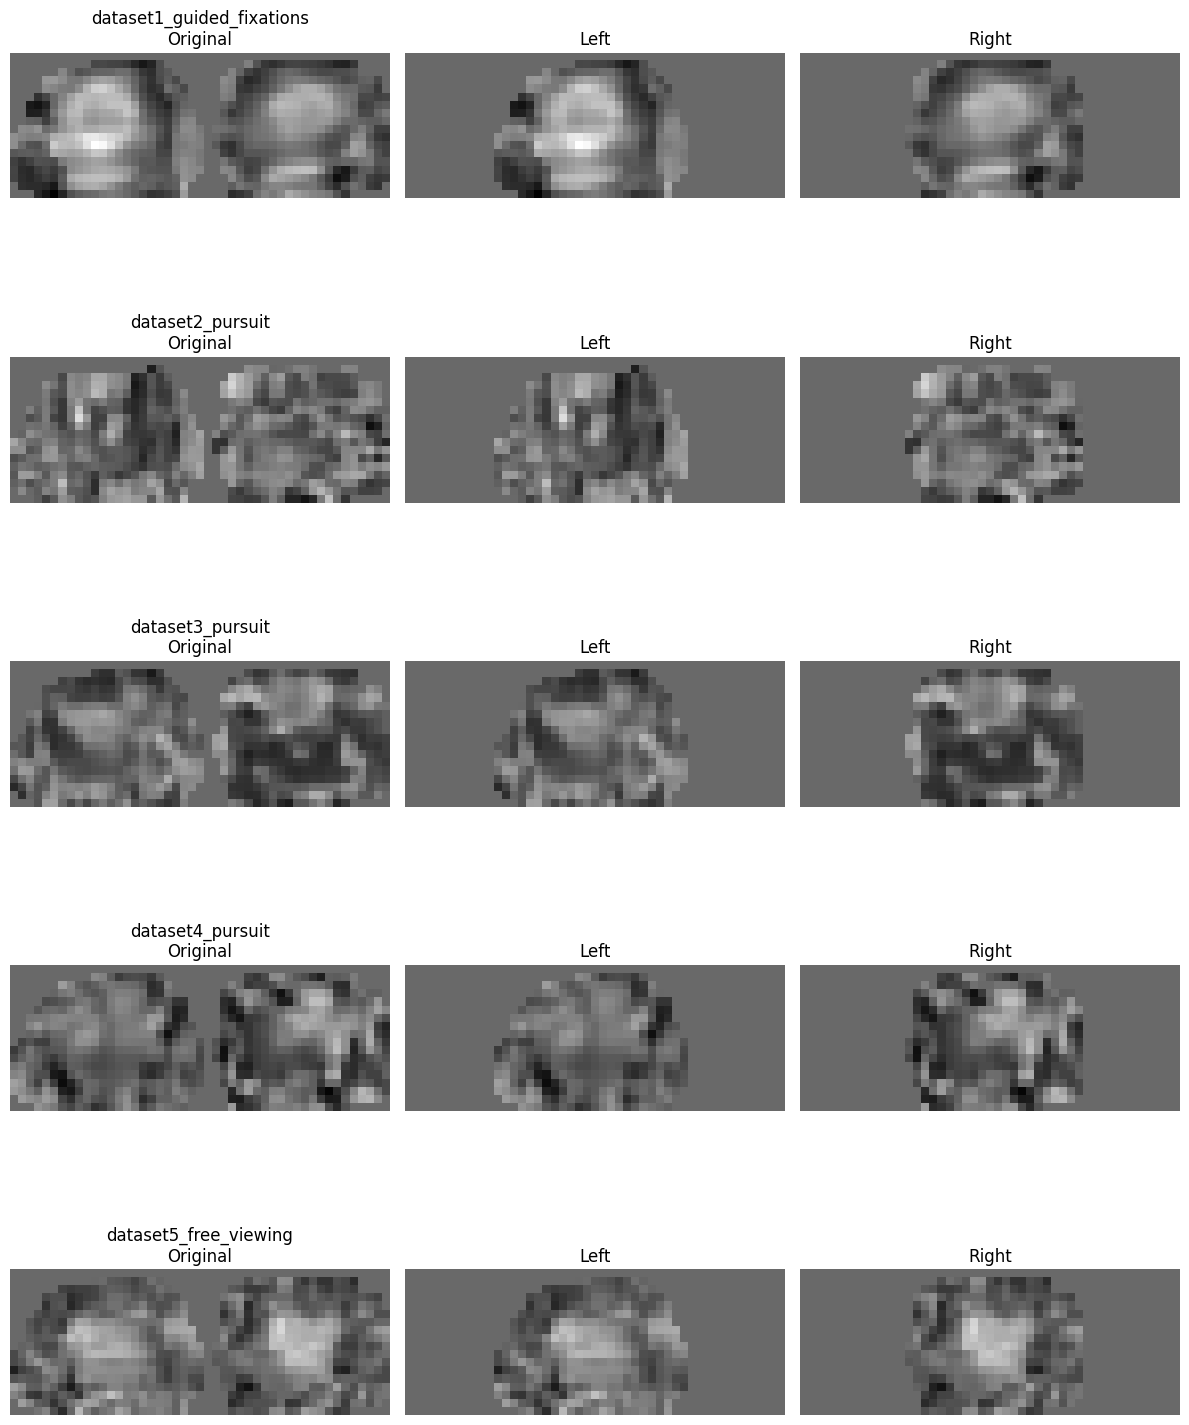

In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt
import random

# dataset folder names
datasets = [
    "dataset1_guided_fixations",
    "dataset2_pursuit",
    "dataset3_pursuit",
    "dataset4_pursuit",
    "dataset5_free_viewing",
]

input_root = "./processed_data"
div_left = "./divided/left"
div_right = "./divided/right"

fig, axes = plt.subplots(len(datasets), 3, figsize=(12, 15))

all_slices = []
slices_dict = {}

# --- helper: pad/crop vertically to match target height ---
def match_height(arr, target_h):
    h, w = arr.shape
    if h == target_h:
        return arr
    elif h > target_h:  # crop
        start = (h - target_h) // 2
        return arr[start:start+target_h, :]
    else:  # pad
        pad_top = (target_h - h) // 2
        pad_bottom = target_h - h - pad_top
        return np.pad(arr, ((pad_top, pad_bottom), (0, 0)), mode="constant")

# --- First pass: load and extract middle slices ---
for ds in datasets:
    ds_path = os.path.join(input_root, ds)
    files = [f for f in os.listdir(ds_path) if f.endswith(".npz")]
    chosen = random.choice(files)

    orig_path = os.path.join(ds_path, chosen)
    base = chosen.replace(".npz", "")
    left_path = os.path.join(div_left, ds, base + "_left.npz")
    right_path = os.path.join(div_right, ds, base + "_right.npz")

    orig = np.load(orig_path)
    left = np.load(left_path)
    right = np.load(right_path)

    data_key = [k for k in orig.keys() if k.startswith("data_")][0]

    arr_orig = orig[data_key]
    arr_left = left[data_key]
    arr_right = right[data_key]

    mid_orig = arr_orig.shape[1] // 2
    mid_left = arr_left.shape[1] // 2
    mid_right = arr_right.shape[1] // 2

    slice_orig = arr_orig[:, mid_orig, :]
    slice_left = arr_left[:, mid_left, :]
    slice_right = arr_right[:, mid_right, :]

    slices_dict[ds] = (slice_orig, slice_left, slice_right)
    all_slices.extend([slice_orig, slice_left, slice_right])

# --- Global intensity scaling ---
vmin = min(s.min() for s in all_slices)
vmax = max(s.max() for s in all_slices)

# --- Second pass: plot ---
for i, ds in enumerate(datasets):
    slice_orig, slice_left, slice_right = slices_dict[ds]

    # keep Original intact
    axes[i, 0].imshow(slice_orig.T, cmap="gray", vmin=vmin, vmax=vmax, aspect="equal")
    axes[i, 0].set_title(f"{ds}\nOriginal")

    # pad/crop left/right to Original height
    orig_h = slice_orig.shape[0]
    left_adj = match_height(slice_left, orig_h)
    right_adj = match_height(slice_right, orig_h)

    axes[i, 1].imshow(left_adj.T, cmap="gray", vmin=vmin, vmax=vmax, aspect="equal")
    axes[i, 1].set_title("Left")
    axes[i, 2].imshow(right_adj.T, cmap="gray", vmin=vmin, vmax=vmax, aspect="equal")
    axes[i, 2].set_title("Right")

    for j in range(3):
        axes[i, j].axis("off")

plt.tight_layout()
plt.subplots_adjust(hspace=0.2)  # smaller = less vertical gap, try 0.1–0.2
plt.show()

In [15]:
test_list_left = get_divided_paths(test_list, eye="left")
train_list_left = get_divided_paths(train_list, eye="left")
test_list_right = get_divided_paths(test_list, eye="right")
train_list_right = get_divided_paths(train_list, eye="right")

In [19]:
generators_left = create_holdout_generators(train_list=train_list_left, test_list=test_list_left, batch_size=opts['batch_size'], augment_list=((opts['rotation_x'], opts['rotation_y'], opts['rotation_z']), opts['shift'], opts['zoom']), mixed_batches=True)

Training set (./divided/left/dataset1_guided_fixations) contains 210 subjects: 
['sub-NDARCU118LMX_left', 'sub-NDARAH503YG1_left', 'sub-NDARVC195NLH_left',
 'sub-NDARGA048BD8_left', 'sub-NDARYE379GGT_left', 'sub-NDARGT551AFK_left',
 'sub-NDARBG188RA5_left', 'sub-NDARXL697DA6_left', 'sub-NDARBT607PZL_left',
 'sub-NDARTB203DU7_left', 'sub-NDARRM073JKA_left', 'sub-NDARVB902GA5_left',
 'sub-NDARWJ498CZY_left', 'sub-NDARDH086ZKK_left', 'sub-NDARBJ482HJL_left',
 'sub-NDARHG065YHQ_left', 'sub-NDARDY776AKH_left', 'sub-NDARRB901DWV_left',
 'sub-NDARWM656UWL_left', 'sub-NDARTC865YNZ_left', 'sub-NDARAP785CTE_left',
 'sub-NDARFA402LMW_left', 'sub-NDARWK104FLX_left', 'sub-NDARRL426AD5_left',
 'sub-NDARPE752VYE_left', 'sub-NDARGV948BFZ_left', 'sub-NDARGK672URV_left',
 'sub-NDAREF893ZM8_left', 'sub-NDARHD931FNA_left', 'sub-NDARPD855ARC_left',
 'sub-NDARKZ634RVX_left', 'sub-NDARJH492TVW_left', 'sub-NDARDE877RFH_left',
 'sub-NDARAG340ERT_left', 'sub-NDARFF644ZGD_left', 'sub-NDARAK738BGC_left',
 'sub-ND

In [24]:
# Train model
(model_left, model_inference_left) = train.train_model(dataset='left_eye', generators=generators_left, opts=opts, use_multiprocessing=True,
                                            return_untrained=False, verbose=1, save=True)

Input shape (8, 24, 29, 18, 1), Output shape (8, 10, 2)
Subjects in training set: 210, Subjects in test set: 54
Epoch 1/25
1500/1500 [==============================] - 161s 95ms/step - loss: 7.5005 - val_loss: 6.3801 - lr: 2.0000e-05
Epoch 2/25
1500/1500 [==============================] - 130s 87ms/step - loss: 6.6073 - val_loss: 5.9242 - lr: 1.9279e-05
Epoch 3/25
1500/1500 [==============================] - 133s 89ms/step - loss: 6.2914 - val_loss: 5.3626 - lr: 1.8554e-05
Epoch 4/25
1500/1500 [==============================] - 129s 86ms/step - loss: 6.1244 - val_loss: 5.4518 - lr: 1.7826e-05
Epoch 5/25
1500/1500 [==============================] - 127s 84ms/step - loss: 5.9017 - val_loss: 5.2541 - lr: 1.7095e-05
Epoch 6/25
1500/1500 [==============================] - 119s 79ms/step - loss: 5.7998 - val_loss: 5.1079 - lr: 1.6361e-05
Epoch 7/25
1500/1500 [==============================] - 111s 74ms/step - loss: 5.6139 - val_loss: 4.9750 - lr: 1.5623e-05
Epoch 8/25
1500/1500 [============

In [25]:
(evaluation_left, scores_left) = train.evaluate_model(dataset='left_eye', model=model_inference_left, generators=generators_left, save=True, model_description='', verbose=2, percentile_cut=80)

1 / 54 - Model Performance for ./divided/left/dataset1_guided_fixations/sub-NDARWA433WYZ_left.npz
              Pearson             R^2-Score             Eucl. Error             
                    X     Y  Mean         X     Y  Mean        Mean Median   Std
Default         0.839 0.831 0.835     0.701 0.685 0.693       3.594  2.526 3.219
Default subTR   0.839 0.831 0.835     0.702 0.685 0.694       3.588  2.527 3.217
Refined         0.879 0.852 0.866     0.772 0.725 0.748       3.048  1.893 3.162
Refined subTR   0.875 0.850 0.863     0.765 0.721 0.743       3.118  1.862 3.205


2 / 54 - Model Performance for ./divided/left/dataset1_guided_fixations/sub-NDARFG713PLR_left.npz
              Pearson             R^2-Score             Eucl. Error             
                    X     Y  Mean         X     Y  Mean        Mean Median   Std
Default         0.581 0.733 0.657     0.288 0.520 0.404       4.910  2.716 4.912
Default subTR   0.581 0.733 0.657     0.286 0.520 0.403       4.912  2.69

In [26]:
fig = analyse.visualise_predictions_slider(evaluation_left, scores_left, color="rgb(0, 150, 175)", bg_color="rgb(255,255,255)", ylim=[-11, 11])
fig.show()

FigureWidget({
    'data': [{'boxpoints': 'all',
              'fillcolor': 'rgb(180, 180, 180)',
              'line': {'color': 'rgb(0,0,0)'},
              'marker': {'color': 'rgb(0, 150, 175)',
                         'line': {'color': 'rgb(0,0,0)', 'width': 2},
                         'opacity': 0.65,
                         'size': 12},
              'name': 'Default',
              'pointpos': 0,
              'text': [participant sub-NDARWA433WYZ_left, participant sub-
                       NDARFG713PLR_left, participant sub-NDARFB908HVX_left,
                       participant sub-NDARVP285RXV_left, participant sub-
                       NDARFM749LF3_left, participant sub-NDARAX272ZJL_left,
                       participant sub-NDARUY730ANT_left, participant sub-
                       NDARAG115LZP_left, participant sub-NDARYC466ER1_left,
                       participant sub-NDARFU916UZY_left, participant sub-
                       NDAREY778CR9_left, participant sub-

In [27]:
generators_right = create_holdout_generators(train_list=train_list_right, test_list=test_list_right, batch_size=opts['batch_size'], augment_list=((opts['rotation_x'], opts['rotation_y'], opts['rotation_z']), opts['shift'], opts['zoom']), mixed_batches=True)

Training set (./divided/right/dataset1_guided_fixations) contains 210 subjects: 
['sub-NDARCU118LMX_right', 'sub-NDARAH503YG1_right', 'sub-NDARVC195NLH_right',
 'sub-NDARGA048BD8_right', 'sub-NDARYE379GGT_right', 'sub-NDARGT551AFK_right',
 'sub-NDARBG188RA5_right', 'sub-NDARXL697DA6_right', 'sub-NDARBT607PZL_right',
 'sub-NDARTB203DU7_right', 'sub-NDARRM073JKA_right', 'sub-NDARVB902GA5_right',
 'sub-NDARWJ498CZY_right', 'sub-NDARDH086ZKK_right', 'sub-NDARBJ482HJL_right',
 'sub-NDARHG065YHQ_right', 'sub-NDARDY776AKH_right', 'sub-NDARRB901DWV_right',
 'sub-NDARWM656UWL_right', 'sub-NDARTC865YNZ_right', 'sub-NDARAP785CTE_right',
 'sub-NDARFA402LMW_right', 'sub-NDARWK104FLX_right', 'sub-NDARRL426AD5_right',
 'sub-NDARPE752VYE_right', 'sub-NDARGV948BFZ_right', 'sub-NDARGK672URV_right',
 'sub-NDAREF893ZM8_right', 'sub-NDARHD931FNA_right', 'sub-NDARPD855ARC_right',
 'sub-NDARKZ634RVX_right', 'sub-NDARJH492TVW_right', 'sub-NDARDE877RFH_right',
 'sub-NDARAG340ERT_right', 'sub-NDARFF644ZGD_right

In [28]:
# Train model
(model_right, model_inference_right) = train.train_model(dataset='right_eye', generators=generators_right, opts=opts, use_multiprocessing=True,
                                            return_untrained=False, verbose=1, save=True)

Input shape (8, 23, 29, 18, 1), Output shape (8, 10, 2)
Subjects in training set: 210, Subjects in test set: 54
Epoch 1/25
1500/1500 [==============================] - 175s 104ms/step - loss: 7.4433 - val_loss: 7.0974 - lr: 2.0000e-05
Epoch 2/25
1500/1500 [==============================] - 135s 90ms/step - loss: 6.7342 - val_loss: 5.9509 - lr: 1.9279e-05
Epoch 3/25
1500/1500 [==============================] - 135s 90ms/step - loss: 6.2772 - val_loss: 5.5207 - lr: 1.8554e-05
Epoch 4/25
1500/1500 [==============================] - 131s 87ms/step - loss: 6.0973 - val_loss: 5.4354 - lr: 1.7826e-05
Epoch 5/25
1500/1500 [==============================] - 130s 87ms/step - loss: 5.9157 - val_loss: 5.2750 - lr: 1.7095e-05
Epoch 6/25
1500/1500 [==============================] - 130s 87ms/step - loss: 5.7937 - val_loss: 5.2690 - lr: 1.6361e-05
Epoch 7/25
1500/1500 [==============================] - 112s 75ms/step - loss: 5.6406 - val_loss: 4.9670 - lr: 1.5623e-05
Epoch 8/25
1500/1500 [===========

In [29]:
(evaluation_right, scores_right) = train.evaluate_model(dataset='right_eye', model=model_inference_right, generators=generators_right, save=True, model_description='', verbose=2, percentile_cut=80)

1 / 54 - Model Performance for ./divided/right/dataset1_guided_fixations/sub-NDARWA433WYZ_right.npz
              Pearson             R^2-Score             Eucl. Error             
                    X     Y  Mean         X     Y  Mean        Mean Median   Std
Default         0.826 0.857 0.841     0.682 0.730 0.706       3.375  2.223 3.410
Default subTR   0.826 0.857 0.841     0.682 0.730 0.706       3.375  2.191 3.415
Refined         0.869 0.891 0.880     0.755 0.791 0.773       2.846  1.652 3.219
Refined subTR   0.872 0.890 0.881     0.759 0.790 0.775       2.840  1.661 3.169


2 / 54 - Model Performance for ./divided/right/dataset1_guided_fixations/sub-NDARFG713PLR_right.npz
              Pearson             R^2-Score             Eucl. Error             
                    X     Y  Mean         X     Y  Mean        Mean Median   Std
Default         0.417 0.639 0.528     0.067 0.401 0.234       6.241  5.191 4.842
Default subTR   0.416 0.639 0.527     0.065 0.400 0.232       6.247  

In [30]:
fig = analyse.visualise_predictions_slider(evaluation_right, scores_right, color="rgb(0, 150, 175)", bg_color="rgb(255,255,255)", ylim=[-11, 11])
fig.show()

FigureWidget({
    'data': [{'boxpoints': 'all',
              'fillcolor': 'rgb(180, 180, 180)',
              'line': {'color': 'rgb(0,0,0)'},
              'marker': {'color': 'rgb(0, 150, 175)',
                         'line': {'color': 'rgb(0,0,0)', 'width': 2},
                         'opacity': 0.65,
                         'size': 12},
              'name': 'Default',
              'pointpos': 0,
              'text': [participant sub-NDARWA433WYZ_right, participant sub-
                       NDARFG713PLR_right, participant sub-NDARFB908HVX_right,
                       participant sub-NDARVP285RXV_right, participant sub-
                       NDARFM749LF3_right, participant sub-NDARAX272ZJL_right,
                       participant sub-NDARUY730ANT_right, participant sub-
                       NDARAG115LZP_right, participant sub-NDARYC466ER1_right,
                       participant sub-NDARFU916UZY_right, participant sub-
                       NDAREY778CR9_right, parti

In [31]:
results_both_eyes=np.load('results_both_eyes.npy', allow_pickle=True)
results_left_eye=np.load('results_left_eye.npy', allow_pickle=True)
results_right_eye=np.load('results_right_eye.npy', allow_pickle=True)

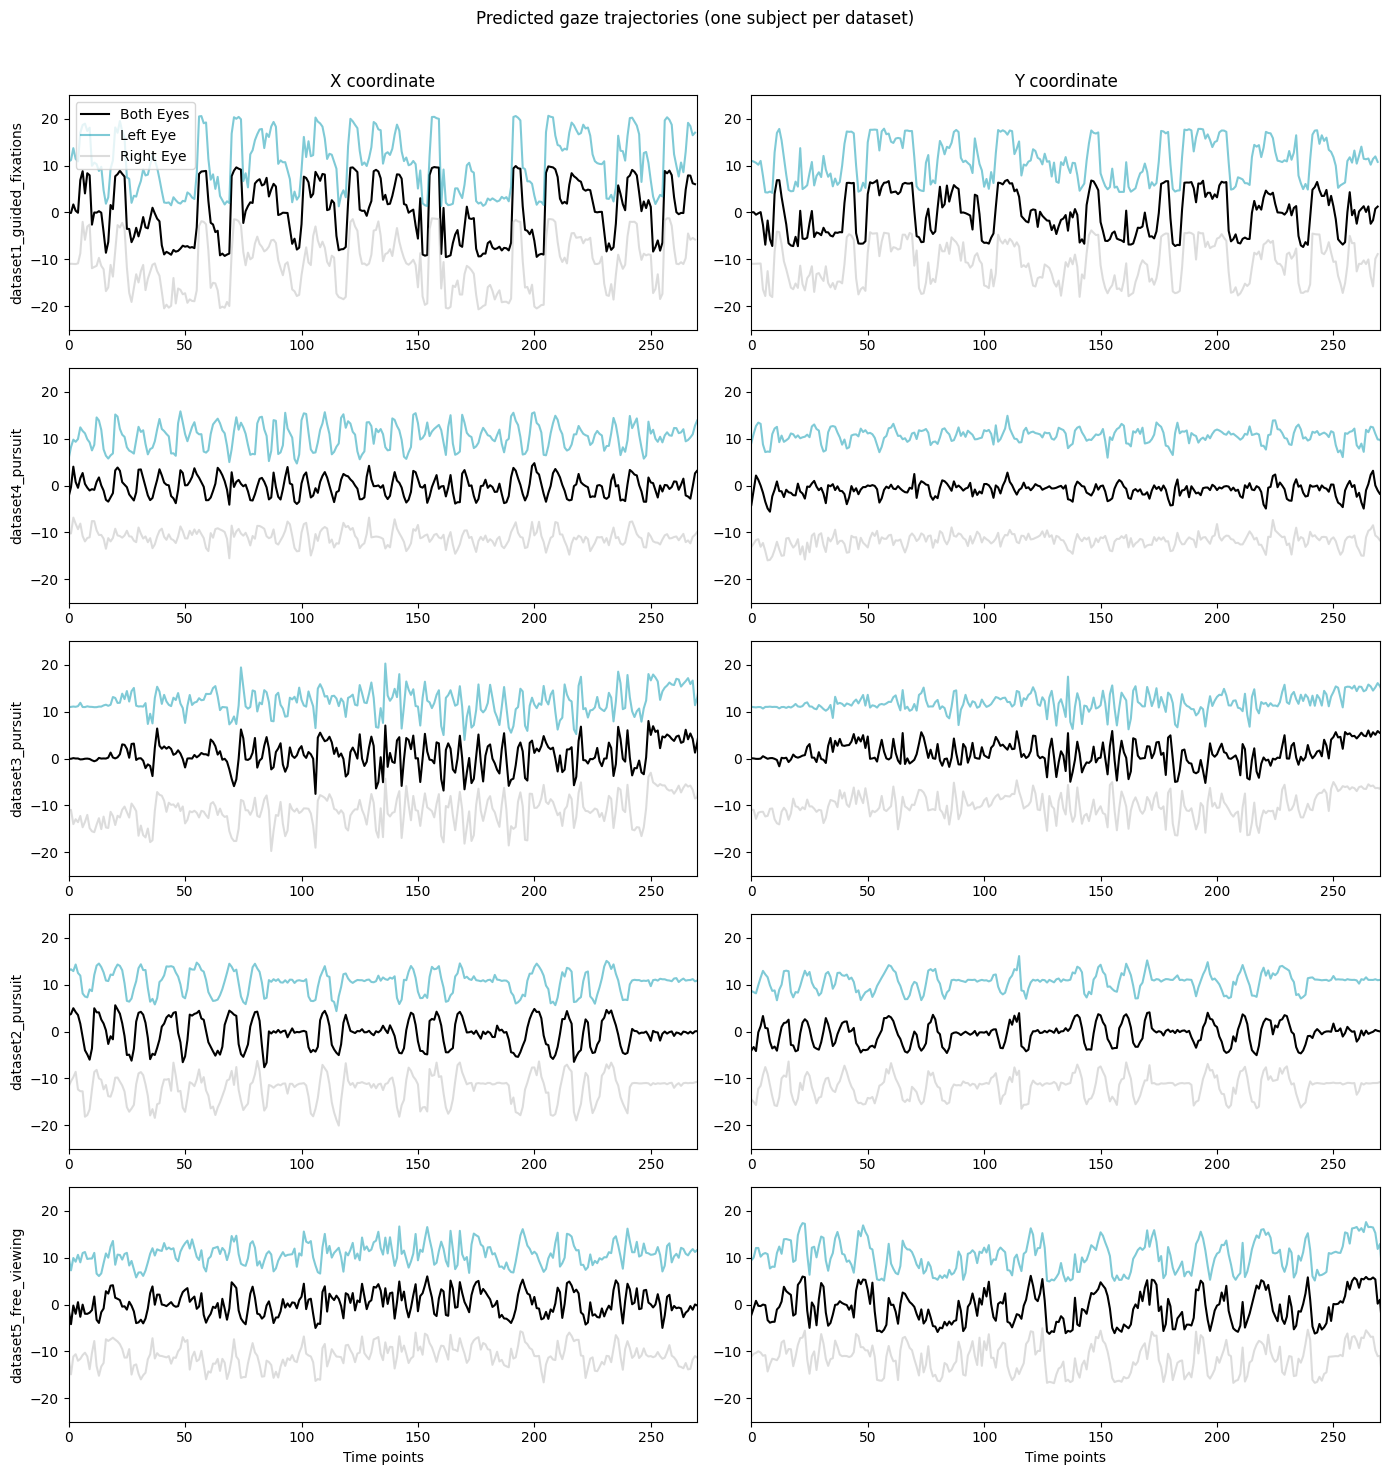

In [173]:
import numpy as np
import matplotlib.pyplot as plt
import random
from collections import defaultdict

# Define colors (convert RGB 0-255 to 0-1)
both_color = (0/255, 0/255, 0/255)
left_color = (0/255, 150/255, 175/255) 
right_color = (187/255, 187/255, 187/255)

# Group Both-Eyes subjects by dataset
dataset_groups = defaultdict(list)
for key in results_both_eyes.keys():
    dataset_name = key.split('/')[2]  # e.g., 'dataset1_guided_fixations'
    dataset_groups[dataset_name].append(key)

# Pick one random subject per dataset
selected_both_keys = [random.choice(keys) for keys in dataset_groups.values()]

fig, axes = plt.subplots(len(selected_both_keys), 2, figsize=(14, 3*len(selected_both_keys)), sharex=False)
fig.patch.set_facecolor(bg_color)  # set figure background

for i, both_key in enumerate(selected_both_keys):
    subj_name = both_key.split('/')[-1].replace('.npz','')

    # Corresponding Left/Right keys
    left_key = both_key.replace("./processed_data", "./divided/left").replace(".npz", "_left.npz")
    right_key = both_key.replace("./processed_data", "./divided/right").replace(".npz", "_right.npz")

    # Median across repetitions
    pred_both = np.median(results_both_eyes[both_key]['pred_y'], axis=1)
    pred_left = np.median(results_left_eye[left_key]['pred_y'], axis=1)
    pred_right = np.median(results_right_eye[right_key]['pred_y'], axis=1)

    n_timepoints = pred_both.shape[0]
    times = np.arange(n_timepoints)

    # X coordinate
    axes[i, 0].plot(times, pred_both[:,0], label="Both Eyes", color=both_color)
    axes[i, 0].plot(times, pred_left[:,0]+11, label="Left Eye", color=left_color, alpha=0.5)
    axes[i, 0].plot(times, pred_right[:,0]-11, label="Right Eye", color=right_color, alpha=0.5)
    axes[i, 0].set_ylabel(f"{both_key.split('/')[2]}")
    axes[i, 0].set_ylim(-25,25)
    axes[i, 0].set_xlim(0, 270)
    axes[i, 0].set_facecolor(bg_color)
    if i == 0:
        axes[i, 0].set_title("X coordinate")
        axes[i, 0].legend()

    # Y coordinate
    axes[i, 1].plot(times, pred_both[:,1], label="Both Eyes", color=both_color)
    axes[i, 1].plot(times, pred_left[:,1]+11, label="Left Eye", color=left_color, alpha=0.5)
    axes[i, 1].plot(times, pred_right[:,1]-11, label="Right Eye", color=right_color, alpha=0.5)
    axes[i, 1].set_ylim(-25,25)
    axes[i, 1].set_xlim(0, 270)
    axes[i, 1].set_facecolor(bg_color)
    if i == 0:
        axes[i, 1].set_title("Y coordinate")

for ax in axes[-1, :]:
    ax.set_xlabel("Time points")

plt.suptitle("Predicted gaze trajectories (one subject per dataset)")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


In [71]:
import re

def extract_subject_id(path, eye=None):
    """Extract subject ID from path, normalizing left/right suffix."""
    filename = path.split("/")[-1].replace(".npz", "")
    
    # Remove _right or _left suffix if eye-specific
    if eye in ["right", "left"]:
        filename = re.sub(r"_(right|left)$", "", filename, flags=re.IGNORECASE)
    
    return filename

# Convert dict keys to sets of subject IDs
both_ids = {extract_subject_id(k) for k in results_both_eyes.keys()}
right_ids = {extract_subject_id(k, eye="right") for k in results_right_eye.keys()}
left_ids = {extract_subject_id(k, eye="left") for k in results_left_eye.keys()}

# Find overlaps and differences
common_all = both_ids & right_ids & left_ids
only_in_both = both_ids - (right_ids | left_ids)
only_in_right = right_ids - (both_ids | left_ids)
only_in_left = left_ids - (both_ids | right_ids)

#print(" Subjects in all three:", sorted(common_all))
total_common = len(both_ids & right_ids & left_ids)
print("Total subjects in all three:", total_common)


Total subjects in all three: 54


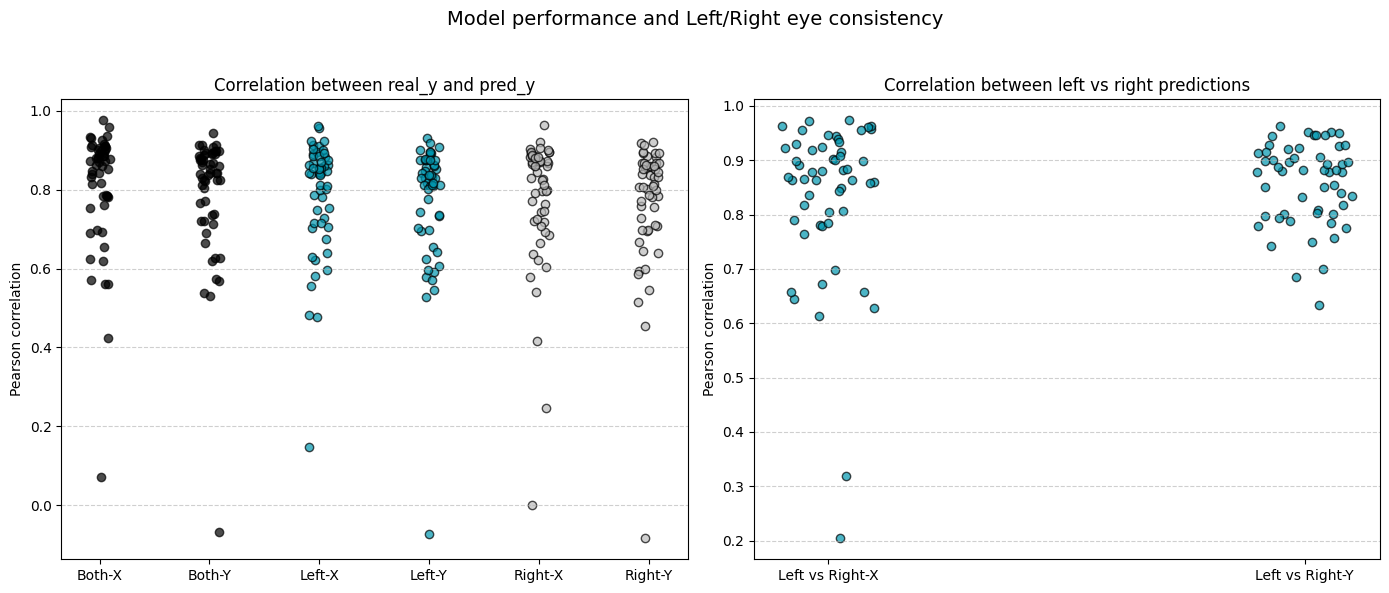

In [168]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Load the results
results_both_eyes = np.load('results_both_eyes.npy', allow_pickle=True).item()
results_left_eye = np.load('results_left_eye.npy', allow_pickle=True).item()
results_right_eye = np.load('results_right_eye.npy', allow_pickle=True).item()

all_results = {
    "Both Eyes": results_both_eyes,
    "Left Eye": results_left_eye,
    "Right Eye": results_right_eye
}

# Define favorite colors
both_color = (0/255, 0/255, 0/255)
left_color = (0/255, 150/255, 175/255)
right_color = (187/255, 187/255, 187/255)
bg_color = (1,1,1)  # white

# ---------- Step 1: Compute correlations ----------
corrs_X, corrs_Y = [], []

for model_name, model_data in all_results.items():
    corr_x_list, corr_y_list = [], []

    for subject, subj_data in model_data.items():
        real_median = np.median(subj_data['real_y'], axis=1)
        pred_median = np.median(subj_data['pred_y'], axis=1)

        mask_x = np.isfinite(real_median[:,0]) & np.isfinite(pred_median[:,0])
        mask_y = np.isfinite(real_median[:,1]) & np.isfinite(pred_median[:,1])

        corr_x = pearsonr(real_median[mask_x,0], pred_median[mask_x,0])[0] if np.sum(mask_x) > 1 else np.nan
        corr_y = pearsonr(real_median[mask_y,1], pred_median[mask_y,1])[0] if np.sum(mask_y) > 1 else np.nan

        corr_x_list.append(corr_x)
        corr_y_list.append(corr_y)

    corrs_X.append(corr_x_list)
    corrs_Y.append(corr_y_list)

# ---------- Step 2: Compute Left vs Right pred correlations ----------
corr_lr_X, corr_lr_Y = [], []

for left_key, right_key in zip(results_left_eye.keys(), results_right_eye.keys()):
    pred_left = np.median(results_left_eye[left_key]['pred_y'], axis=1)
    pred_right = np.median(results_right_eye[right_key]['pred_y'], axis=1)

    mask_x = np.isfinite(pred_left[:,0]) & np.isfinite(pred_right[:,0])
    mask_y = np.isfinite(pred_left[:,1]) & np.isfinite(pred_right[:,1])

    corr_lr_X.append(pearsonr(pred_left[mask_x,0], pred_right[mask_x,0])[0] if np.sum(mask_x) > 1 else np.nan)
    corr_lr_Y.append(pearsonr(pred_left[mask_y,1], pred_right[mask_y,1])[0] if np.sum(mask_y) > 1 else np.nan)

# ---------- Step 3: Plot with strip plots ----------
fig, axes = plt.subplots(1, 2, figsize=(14,6), facecolor=bg_color)

# Left subplot: real_y vs pred_y correlations
all_data = [corrs_X[0], corrs_Y[0], corrs_X[1], corrs_Y[1], corrs_X[2], corrs_Y[2]]
colors = [both_color, both_color, left_color, left_color, right_color, right_color]
positions = [1,2,3,4,5,6]

for pos, data, color in zip(positions, all_data, colors):
    x_jitter = np.random.uniform(-0.1, 0.1, size=len(data))
    axes[0].scatter(np.ones(len(data))*pos + x_jitter, data, color=color, alpha=0.7, edgecolor='black')

axes[0].set_xticks(positions)
axes[0].set_xticklabels(["Both-X", "Both-Y", "Left-X", "Left-Y", "Right-X", "Right-Y"])
axes[0].set_ylabel("Pearson correlation")
axes[0].set_title("Correlation between real_y and pred_y")
axes[0].grid(axis='y', linestyle='--', alpha=0.6)
axes[0].set_facecolor(bg_color)

# Right subplot: Left vs Right pred correlations
all_data_lr = [corr_lr_X, corr_lr_Y]
colors_lr = [left_color, left_color]
positions_lr = [1,2]

for pos, data, color in zip(positions_lr, all_data_lr, colors_lr):
    x_jitter = np.random.uniform(-0.1, 0.1, size=len(data))
    axes[1].scatter(np.ones(len(data))*pos + x_jitter, data, color=color, alpha=0.7, edgecolor='black')

axes[1].set_xticks(positions_lr)
axes[1].set_xticklabels(["Left vs Right-X", "Left vs Right-Y"])
axes[1].set_ylabel("Pearson correlation")
axes[1].set_title("Correlation between left vs right predictions")
axes[1].grid(axis='y', linestyle='--', alpha=0.6)
axes[1].set_facecolor(bg_color)

plt.suptitle("Model performance and Left/Right eye consistency", fontsize=14)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


Correlation between Both-Eyes performance and Left-Right consistency:
X-axis: r = 0.346, p = 1.034e-02
Y-axis: r = 0.566, p = 8.176e-06


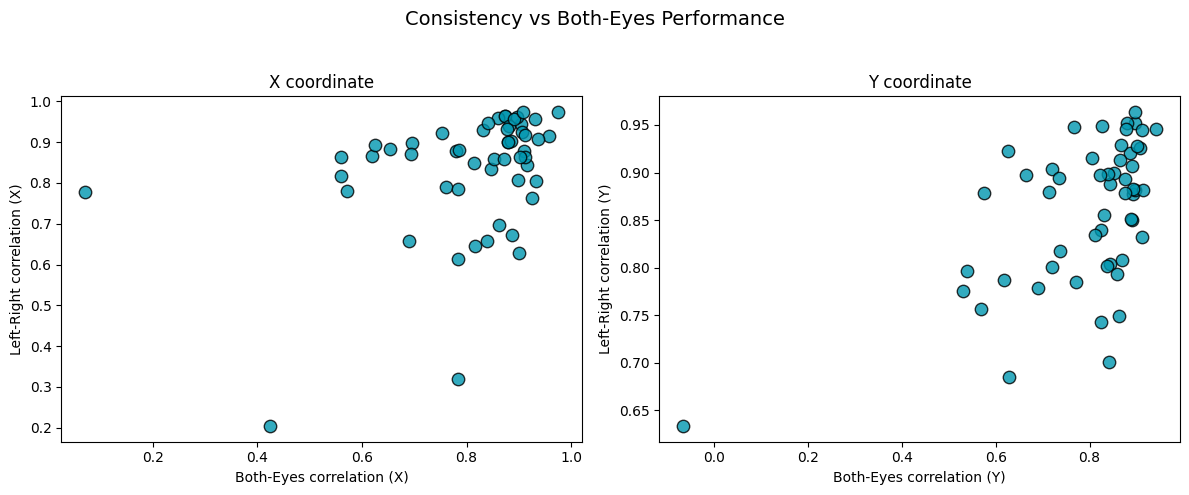

In [156]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Define favorite colors
both_color = (0/255, 0/255, 0/255)        # black
left_color = (0/255, 150/255, 175/255)   # turquoise
right_color = (187/255, 187/255, 187/255) # light gray
bg_color = (255/255, 255/255, 255/255)   # white

both_corr_X, both_corr_Y = [], []
lr_corr_X, lr_corr_Y = [], []

for left_key, right_key, both_key in zip(results_left_eye.keys(), results_right_eye.keys(), results_both_eyes.keys()):
    # Median across repetitions
    pred_left = np.median(results_left_eye[left_key]['pred_y'], axis=1)
    pred_right = np.median(results_right_eye[right_key]['pred_y'], axis=1)
    pred_both = np.median(results_both_eyes[both_key]['pred_y'], axis=1)
    real_both = np.median(results_both_eyes[both_key]['real_y'], axis=1)

    # Filter NaNs/Infs
    mask_both_X = np.isfinite(real_both[:,0]) & np.isfinite(pred_both[:,0])
    mask_both_Y = np.isfinite(real_both[:,1]) & np.isfinite(pred_both[:,1])
    mask_lr_X = np.isfinite(pred_left[:,0]) & np.isfinite(pred_right[:,0])
    mask_lr_Y = np.isfinite(pred_left[:,1]) & np.isfinite(pred_right[:,1])

    # Correlations
    both_corr_X.append(pearsonr(real_both[mask_both_X,0], pred_both[mask_both_X,0])[0] if np.sum(mask_both_X)>1 else np.nan)
    both_corr_Y.append(pearsonr(real_both[mask_both_Y,1], pred_both[mask_both_Y,1])[0] if np.sum(mask_both_Y)>1 else np.nan)
    lr_corr_X.append(pearsonr(pred_left[mask_lr_X,0], pred_right[mask_lr_X,0])[0] if np.sum(mask_lr_X)>1 else np.nan)
    lr_corr_Y.append(pearsonr(pred_left[mask_lr_Y,1], pred_right[mask_lr_Y,1])[0] if np.sum(mask_lr_Y)>1 else np.nan)

# Across subjects
consistency_vs_perf_X = pearsonr(np.array(both_corr_X), np.array(lr_corr_X))
consistency_vs_perf_Y = pearsonr(np.array(both_corr_Y), np.array(lr_corr_Y))

print("Correlation between Both-Eyes performance and Left-Right consistency:")
print(f"X-axis: r = {consistency_vs_perf_X[0]:.3f}, p = {consistency_vs_perf_X[1]:.3e}")
print(f"Y-axis: r = {consistency_vs_perf_Y[0]:.3f}, p = {consistency_vs_perf_Y[1]:.3e}")

# Plot figure
fig, axes = plt.subplots(1, 2, figsize=(12,5), facecolor=bg_color)

# X-axis correlation
axes[0].scatter(both_corr_X, lr_corr_X, color=left_color, edgecolor=both_color, s=80, alpha=0.8)
axes[0].set_xlabel("Both-Eyes correlation (X)")
axes[0].set_ylabel("Left-Right correlation (X)")
axes[0].grid(False)
axes[0].set_facecolor(bg_color)
axes[0].set_title("X coordinate")

# Y-axis correlation
axes[1].scatter(both_corr_Y, lr_corr_Y, color=left_color, edgecolor=both_color, s=80, alpha=0.8)
axes[1].set_xlabel("Both-Eyes correlation (Y)")
axes[1].set_ylabel("Left-Right correlation (Y)")
axes[1].grid(False)
axes[1].set_facecolor(bg_color)
axes[1].set_title("Y coordinate")

plt.suptitle("Consistency vs Both-Eyes Performance", fontsize=14)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


In [20]:
# Loading model weights 

# Get untrained model and load with trained weights
generators = create_holdout_generators(train_list=train_list, test_list=test_list, batch_size=opts['batch_size'], augment_list=((opts['rotation_x'], opts['rotation_y'], opts['rotation_z']), opts['shift'], opts['zoom']), mixed_batches=True)

(model, model_inference) = train.train_model(dataset="example_data",
                                             generators=generators,
                                             opts=opts,
                                             return_untrained=True)
model_inference.load_weights('modelinference_both_eyes.h5')

Training set (./processed_data/dataset1_guided_fixations) contains 210 subjects: 
['sub-NDARGC148JBJ', 'sub-NDARAT358XM9', 'sub-NDARAK738BGC', 'sub-NDARND697FLK',
 'sub-NDARKV807EMJ', 'sub-NDARKD064EVC', 'sub-NDARFU916UZY', 'sub-NDARPZ344ZGE',
 'sub-NDARXE193CZ1', 'sub-NDARXZ902NFM', 'sub-NDARDB146NWY', 'sub-NDARRB901DWV',
 'sub-NDAREM731BYM', 'sub-NDARCJ363KLE', 'sub-NDARNU770PM5', 'sub-NDARJF517HC8',
 'sub-NDARAE012DGA', 'sub-NDARBN365EV3', 'sub-NDARFE299MWU', 'sub-NDARBG188RA5',
 'sub-NDARPD855ARC', 'sub-NDARBW403EVZ', 'sub-NDAREE675XRY', 'sub-NDARED628HMQ',
 'sub-NDARGK041TPB', 'sub-NDARAA948VFH', 'sub-NDARZJ587UZU', 'sub-NDARHX963YU1',
 'sub-NDARXR346UT5', 'sub-NDARRZ927VC3', 'sub-NDARDR439HY2', 'sub-NDARDH086ZKK',
 'sub-NDARVN363NNQ', 'sub-NDARHD507TEF', 'sub-NDARGJ395FKP', 'sub-NDARPE752VYE',
 'sub-NDARZK601NG9', 'sub-NDARJG298YVA', 'sub-NDARDN393BJH', 'sub-NDARHG188YE9',
 'sub-NDARJH492TVW', 'sub-NDARFF644ZGD', 'sub-NDARGN044FE4', 'sub-NDARER970AEF',
 'sub-NDARTT272WT5', 'sub-N